# End-to-End decoding by EEGSPDNet
This notebook uses EEGSPDNet (Wilson et al., 2024) to perform End-to-End decoding of visual semantic stimuli of EEG signals.<br>
It uses a SPDNet preceded by region (or channel, as usually refered in the literature) convolutional layers.

I will use the spd_learn library as first to access the potential of each method.<br>
I could - and maybe I will - implement this on my own if this is a godd approach.

In [1]:
# Lib
import sys
sys.path.append("/home/rffl/files/ic/utils/")

import torch
import datagen, eegdataset #type: ignore
from spd_learn.models import EEGSPDNet
from torch.utils.data import DataLoader
from torchmetrics.classification import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Data

In [9]:
# Data config
classVec = [i+1 for i in range(10)]
subVec = [i+1 for i in range(10)]

nClass = len(classVec)
nSub = len(subVec)

In [14]:
# Data gen
train_path, test_path = datagen.generatedataset(classVec, subVec, 0.75, False)

Saved ./train.npy shape = (6000, 17, 100)
Saved ./test.npy shape = (2000, 17, 100)


In [15]:
# xDAWN treatment
import pyriemann as rmn
xDAWNfilters = 10
estimator = "lwf"

X_train = np.load(train_path, allow_pickle=True)
X_test = np.load(test_path, allow_pickle=True)

y_train = np.array([])
part = len(X_train) // len(classVec)
for i in range(len(classVec)):
    y_train = np.concatenate([y_train, i * np.ones(part)])

xdawn = rmn.estimation.Xdawn(nfilter=xDAWNfilters, estimator=estimator)
xdawn.fit(X_train, y_train)

X_train = np.einsum('fc,nct->nft', xdawn.filters_, X_train)
X_test  = np.einsum('fc,nct->nft', xdawn.filters_, X_test)

np.save(train_path, X_train )
np.save(test_path, X_test )

In [18]:
# Dataset and Dataloader init
trainDataset = eegdataset.KClassDataset(nClass, "./train.npy")
trainLoader = DataLoader(trainDataset, 40, True, num_workers=4)

testDataset = eegdataset.KClassDataset(nClass, "./test.npy")
testLoader = DataLoader(testDataset, 40, True, num_workers=4)

### Utilitary functions

In [6]:
import time
def regular_train(model, classVec, trainLoader, testLoader, epochs, device):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_hist_loss = []
    test_hist_loss = []

    train_hist_acc = []
    test_hist_acc = []

    begin = time.time()
    print(f"Begin {begin}")
    for epoch in range(epochs):
        train_loss, train_acc = train(model, trainLoader, criterion, optimizer, device)
        test_loss, test_acc = test(model, testLoader, criterion, device)
        train_hist_loss.append(train_loss); train_hist_acc.append(train_acc)
        test_hist_loss.append(test_loss); test_hist_acc.append(test_acc)
        print(f"Epoch {epoch+1}: "
        f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"Test loss {test_loss:.4f}, acc {test_acc:.4f} | "
        f"Time {time.time() - begin} s")

    confmat = ConfusionMatrix(task="multiclass", num_classes=len(classVec))    

    fig, axs = plt.subplots(1,2)
    axs[0].plot(range(epochs), train_hist_loss, label="Train Loss")
    axs[0].plot(range(epochs), test_hist_loss, label="Test Loss")
    axs[0].legend()

    axs[1].plot(range(epochs), train_hist_acc, label="Train Accuracy")
    axs[1].plot(range(epochs), test_hist_acc, label="Test Accuracy")
    axs[1].legend()
    fig.show()

    for X, y in testLoader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        confmat.update(preds.cpu(), y.cpu())

    confmatrix = confmat.compute()
    plot_confusion_matrix(confmatrix, classVec)

def train(model, trainLoader, criterion, optimizer, device):
    torch.cuda.empty_cache()
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in trainLoader:
        X = X.to(device); y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(trainLoader)
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def test(model, testLoader, criterion, device):
    torch.cuda.empty_cache()
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in testLoader:
        X = X.to(device); y = y.to(device)

        y_hat = model(X)
        total_loss += criterion(y_hat, y).item()

        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(testLoader)
    acc = correct / total
    return avg_loss, acc

def plot_confusion_matrix(confmatrix, class_names=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(confmatrix, interpolation='nearest')
    plt.title("Confusion Matrix")
    plt.colorbar()

    num_classes = confmatrix.shape[0]

    # Tick labels
    if not class_names:
        class_names = [str(i) for i in range(num_classes)]

    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.yticks(range(num_classes), class_names)

    # Print values inside cells
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(confmatrix[i, j].item()),
                     ha="center", va="center", color="white" if confmatrix[i, j] > confmatrix.max()/2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

### Adaptative LWF shrinkage addition

In [2]:
from spd_learn.modules import Shrinkage

class EEGSPDNetLWF(EEGSPDNet):
    def __init__(self, *args, initShrinkage=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        n_cov = self.n_chans * self.n_filters
        self.shrinkage = Shrinkage(n_chans=n_cov, init_shrinkage=initShrinkage, learnable=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.cov_pool(x)
        x = self.shrinkage(x)
        x = self.spdnet(x)
        x = self.dropout(x)
        x = self.linear(x)
        return x

In [ ]:
model = EEGSPDNetLWF(50, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 25, final_layer_drop_prob=0.25, spd_drop_prob=0.25).to(device)
model

Trainable parameters: 451,761


: 

### Train

Begin 1780511502.3684385


Epoch 1: Train loss 2.4409, acc 0.1148 | Test loss 2.4357, acc 0.1250 | Time 111.2233407497406 s
Epoch 2: Train loss 2.3981, acc 0.1288 | Test loss 2.3822, acc 0.1770 | Time 258.2638416290283 s
Epoch 3: Train loss 2.3626, acc 0.1482 | Test loss 2.3534, acc 0.1990 | Time 370.1413130760193 s
Epoch 4: Train loss 2.3417, acc 0.1622 | Test loss 2.4120, acc 0.1915 | Time 482.16364765167236 s
Epoch 5: Train loss 2.3000, acc 0.1748 | Test loss 2.3282, acc 0.2105 | Time 594.047012090683 s
Epoch 6: Train loss 2.2739, acc 0.1870 | Test loss 2.3625, acc 0.2030 | Time 705.9734904766083 s
Epoch 7: Train loss 2.2941, acc 0.1938 | Test loss 2.6509, acc 0.1865 | Time 817.34326338768 s
Epoch 8: Train loss 2.2194, acc 0.2152 | Test loss 2.5069, acc 0.2080 | Time 929.0059144496918 s
Epoch 9: Train loss 2.2432, acc 0.2032 | Test loss 2.4553, acc 0.2155 | Time 1040.4373941421509 s
Epoch 10: Train loss 2.1859, acc 0.2245 | Test loss 2.8014, acc 0.2130 | Time 1152.24791097641 s
Epoch 11: Train loss 2.1861, ac

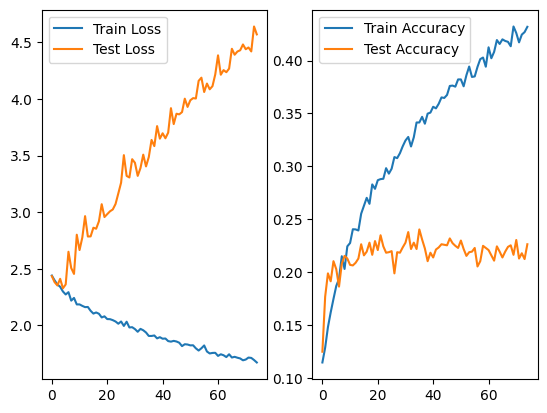

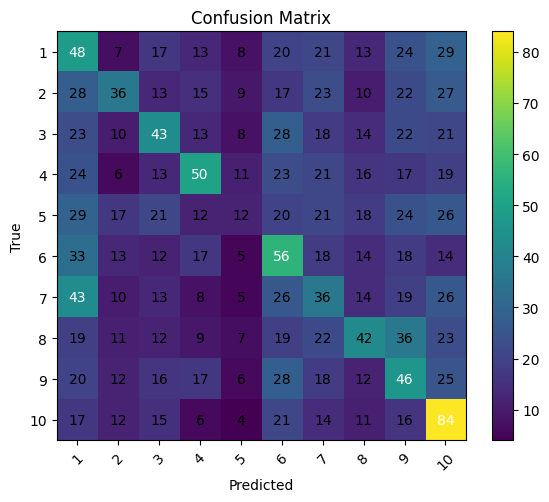

In [40]:
model = EEGSPDNetLWF(50, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 25, final_layer_drop_prob=0.25, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

In [8]:
model = EEGSPDNetLWF(50, 10, n_filters=5, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.5, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

Begin 1780585363.1300387
Epoch 1: Train loss 2.3951, acc 0.1200 | Test loss 2.1750, acc 0.2030 | Time 39.79241442680359 s
Epoch 2: Train loss 2.3067, acc 0.1495 | Test loss 2.0699, acc 0.2660 | Time 79.52503633499146 s
Epoch 3: Train loss 2.2230, acc 0.1952 | Test loss 2.0670, acc 0.2695 | Time 119.46374249458313 s
Epoch 4: Train loss 2.1596, acc 0.2188 | Test loss 2.0070, acc 0.3005 | Time 159.23413586616516 s
Epoch 5: Train loss 2.1303, acc 0.2365 | Test loss 1.9911, acc 0.3205 | Time 199.1219403743744 s
Epoch 6: Train loss 2.0808, acc 0.2563 | Test loss 1.9707, acc 0.3270 | Time 239.27256178855896 s
Epoch 7: Train loss 2.0702, acc 0.2610 | Test loss 2.0173, acc 0.3285 | Time 279.2322669029236 s
Epoch 8: Train loss 2.0390, acc 0.2818 | Test loss 2.0264, acc 0.3420 | Time 319.2517342567444 s
Epoch 9: Train loss 2.0154, acc 0.2910 | Test loss 2.0456, acc 0.3305 | Time 359.21568775177 s
Epoch 10: Train loss 2.0056, acc 0.2892 | Test loss 2.0911, acc 0.3395 | Time 399.60371494293213 s
Ep

KeyboardInterrupt: 

In [19]:
# with 10 xDawn filters
model = EEGSPDNetLWF(100, 10, n_filters=5, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.5, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

Begin 1780586406.8914926


Epoch 1: Train loss 2.4540, acc 0.1165 | Test loss 2.1458, acc 0.2135 | Time 103.13063526153564 s
Epoch 2: Train loss 2.3250, acc 0.1717 | Test loss 2.0912, acc 0.2595 | Time 207.07100105285645 s
Epoch 3: Train loss 2.1962, acc 0.2165 | Test loss 1.9918, acc 0.3155 | Time 310.83076643943787 s
Epoch 4: Train loss 2.1097, acc 0.2503 | Test loss 2.0640, acc 0.3040 | Time 414.68882274627686 s
Epoch 5: Train loss 2.0496, acc 0.2798 | Test loss 2.0834, acc 0.3165 | Time 518.6492033004761 s
Epoch 6: Train loss 2.0165, acc 0.2943 | Test loss 2.1644, acc 0.3185 | Time 622.4073433876038 s
Epoch 7: Train loss 1.9703, acc 0.3172 | Test loss 2.0825, acc 0.3380 | Time 726.3453462123871 s
Epoch 8: Train loss 1.9268, acc 0.3365 | Test loss 2.0811, acc 0.3495 | Time 830.2463173866272 s
Epoch 9: Train loss 1.9131, acc 0.3452 | Test loss 2.0938, acc 0.3635 | Time 934.1253023147583 s
Epoch 10: Train loss 1.8819, acc 0.3425 | Test loss 2.1826, acc 0.3610 | Time 1037.8060789108276 s
Epoch 11: Train loss 1.8

KeyboardInterrupt: 